# Asistente Multiagente para Seguimiento de Iniciativas Tecnológicas con LangGraph

## Problema
La información de las iniciativas está distribuida entre documentación, seguimiento y repositorios.

## Objetivo
Coordinar agentes especializados para consultar y actualizar información de iniciativas. El sistema utiliza Ollama para interpretar la pregunta y reglas determinísticas como respaldo.

## Arquitectura

```mermaid
flowchart TD
    A[START] --> B[Supervisor con LLM o reglas]
    B --> C{Routing condicional}
    C --> D[Iniciativas]
    C --> E[Procedimientos]
    C --> F[Seguimiento]
    C --> G[Estado técnico]
    C --> U[Actualización]
    D --> H[Consolidador]
    E --> H
    F --> H
    G --> H
    U --> H
    H --> I[END]
```

En consultas compuestas, el routing encadena varios agentes. El nodo de actualización permite agregar actores de forma controlada y persistirlos en `initiatives.json`.

## Datos, State y agentes
Los JSON de `data/` contienen iniciativas, procedimientos, seguimiento, Specs y evidencia simulada de GitHub. `InitiativeState` comparte la pregunta, intención, agentes requeridos, resultados, errores y traza.

El Supervisor usa Ollama de manera opcional para interpretar la intención y el nombre de la iniciativa. Si Ollama falla, utiliza reglas determinísticas. Además, valida la clasificación del LLM con reglas de negocio antes del routing: `cómo va` corresponde a iniciativas, `qué falta` a seguimiento, `avance técnico` a estado técnico y `cómo hago un pase` a procedimientos. Los datos y el avance técnico siempre provienen de Python y JSON; el LLM no los inventa ni calcula.

In [5]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

from src.graph import graph, ask
print('Proyecto cargado correctamente')

Proyecto cargado correctamente


## Visualización del grafo

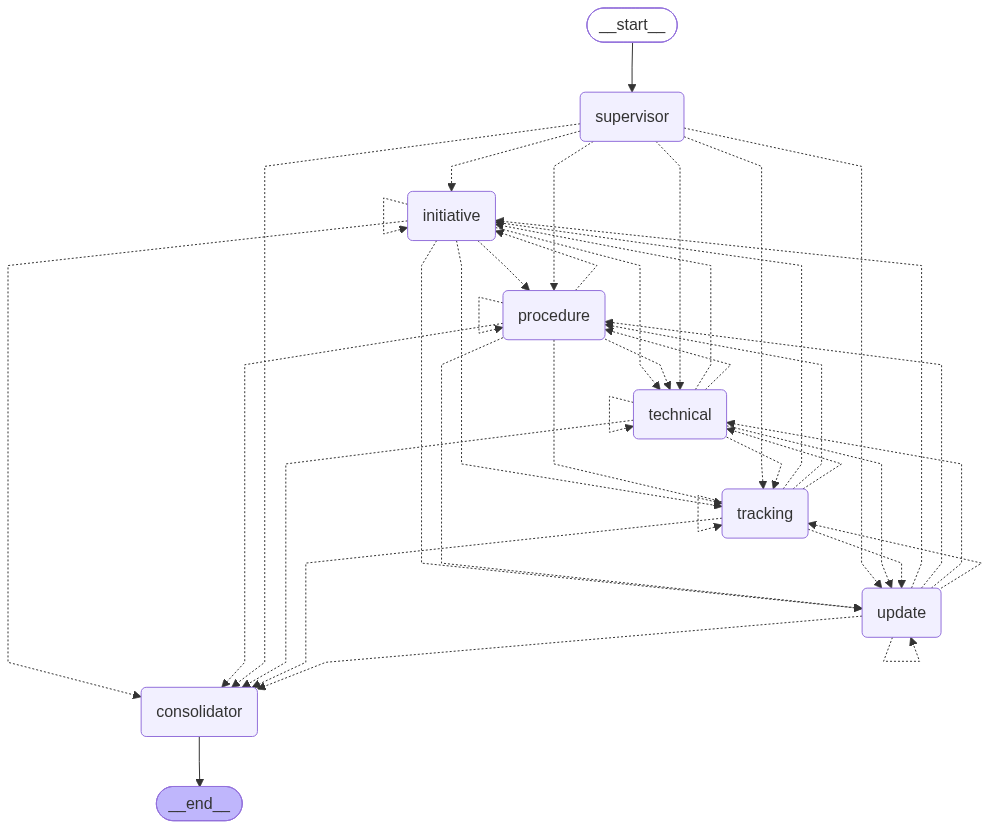

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

## Casos principales de consulta

In [ ]:
questions = [
    '¿Cuál es el estado de Samsung Pay?',
    '¿Cómo hago un pase a producción?',
    '¿Qué falta para Samsung Pay?',
    '¿Cuál es el avance técnico de Samsung Pay?',
    '¿Cómo va Samsung Pay y qué falta para pasar a producción?',
    '¿Cómo va Apple Pay?',
]

for question in questions:
    print('\n' + '=' * 70)
    print(question)
    ask(question)

## Consultas en lenguaje natural
Estos casos comprueban que el Supervisor reconoce consultas generales aunque el usuario no utilice palabras exactas. La respuesta incluye descripción, objetivo, alcance, estado y actores.

In [ ]:
natural_questions = [
    'Dime cómo va la iniciativa de Samsung Pay',
    'Dame la descripción de Samsung',
    'Dame información de COFT Amex',
]

for question in natural_questions:
    print('\n' + '=' * 70)
    print(question)
    ask(question)

## Actualización controlada
El `Update Agent` permite agregar un actor a una iniciativa. Evita duplicados y guarda el cambio en `data/initiatives.json`. Esta versión no permite modificar libremente porcentajes, fechas ni evidencia técnica.

In [ ]:
ask('Quiero agregar un actor más a la iniciativa Samsung, sería Thales')
print('\nConsulta posterior para comprobar la persistencia:')
ask('¿Cómo va la iniciativa Samsung?')

## Ejemplos completos de consulta y respuesta

### 1. Información general de una iniciativa

**Pregunta:** `¿Cómo va la iniciativa Samsung Pay?`

```text
INICIATIVA: Samsung Pay Visa
Descripción: Habilitación de tarjetas Visa en Samsung Pay.
Objetivo: Permitir la tokenización y uso seguro de tarjetas Visa.
Alcance: API de tokenización, integración con Samsung Pay y validaciones.
Estado: UAT
Ambiente: UAT
Próximo hito: Producción
Responsable: Equipo Wallets
Actores: Negocio, Desarrollo, QA, Operaciones, Thales
Fecha objetivo: 2026-09-30

RUTA LANGGRAPH
Supervisor (LLM) → Initiative Agent → Consolidator → END
```

### 2. Descripción en lenguaje natural

**Pregunta:** `Dame la descripción de Samsung`

```text
INICIATIVA: Samsung Pay Visa
Descripción: Habilitación de tarjetas Visa en Samsung Pay.
Objetivo: Permitir la tokenización y uso seguro de tarjetas Visa.
Alcance: API de tokenización, integración con Samsung Pay y validaciones.
Estado: UAT

RUTA LANGGRAPH
Supervisor (LLM) → Initiative Agent → Consolidator → END
```

### 3. Procedimiento

**Pregunta:** `¿Cómo hago un pase a producción?`

```text
PROCEDIMIENTO: Pase a producción
Objetivo: Desplegar un cambio aprobado de forma controlada.
Precondiciones:
- QA aprobado
- Evidencia de seguridad aprobada
- Plan de reversa
Pasos:
1. Registrar solicitud
2. Obtener aprobaciones
3. Ejecutar despliegue
4. Validar operación
Responsable: Operaciones
Resultado esperado: Cambio operativo en producción

RUTA LANGGRAPH
Supervisor (LLM) → Procedure Agent → Consolidator → END
```

### 4. Seguimiento

**Pregunta:** `¿Qué falta para Samsung Pay?`

```text
SEGUIMIENTO
Pendientes:
- Completar pruebas unitarias
- Configurar pipeline CI/CD
- Ejecutar pruebas QA
Bloqueos:
- Ninguno crítico
Próximo paso: Completar pruebas antes de solicitar pase a producción

RUTA LANGGRAPH
Supervisor (LLM) → Tracking Agent → Consolidator → END
```

### 5. Estado técnico

**Pregunta:** `¿Cuál es el avance técnico de Samsung Pay?`

```text
AVANCE TÉCNICO ESTIMADO: 75 %
Cálculo: (20×1 + 25×1 + 20×1 + 20×0.5 + 15×0) / 100
Implementado:
- API de tokenización
- Integración Samsung Pay
- Validación de criptograma
Parcial:
- Pruebas unitarias
Pendiente:
- Pipeline CI/CD

RUTA LANGGRAPH
Supervisor (LLM) → Technical Status Agent → Consolidator → END
```

### 6. Consulta compuesta

**Pregunta:** `¿Cómo va Samsung Pay y qué falta para pasar a producción?`

```text
INICIATIVA: Samsung Pay Visa
Estado: UAT
Avance técnico estimado: 75 %
Implementado: API de tokenización, Integración Samsung Pay y Validación de criptograma
Parcial: Pruebas unitarias
Pendiente: Pipeline CI/CD
Seguimiento: completar pruebas unitarias, pipeline y pruebas QA
Procedimiento: Pase a producción
Próximo paso: completar pruebas antes de solicitar el pase

RUTA LANGGRAPH
Supervisor (LLM) → Initiative Agent → Tracking Agent → Technical Status Agent
→ Procedure Agent → Consolidator → END
```

### 7. Actualización de un actor

**Pregunta:** `Agregar el actor Thales a la iniciativa Samsung`

```text
ACTUALIZACIÓN
Actor Thales agregado correctamente a Samsung Pay Visa.

RUTA LANGGRAPH
Supervisor (LLM) → Update Agent → Consolidator → END
```

Si ya existe, responde: `El actor Thales ya pertenece a Samsung Pay Visa.`

### 8. Nombre escrito incorrectamente

**Pregunta:** `¿Cómo va Samsun pei?`

```text
INICIATIVA: Samsung Pay Visa
Estado: UAT
Ambiente: UAT
Próximo hito: Producción

RUTA LANGGRAPH
Supervisor (LLM) → Initiative Agent → Consolidator → END
```

### 9. Iniciativa inexistente

**Pregunta:** `¿Cómo va Apple Pay?`

```text
No encontré la iniciativa solicitada.
Iniciativas disponibles:
- Samsung Pay Visa
- Migración Azure DevOps a GitHub Actions
- COFT Amex

RUTA LANGGRAPH
Supervisor (LLM) → Consolidator → END
```

> Si Ollama no está disponible, las respuestas conservan los mismos datos y la ruta comienza con `Supervisor (reglas)`.

## Transparencia y uso ético de IA

Para desarrollar esta tarea se utilizó **Codex como herramienta de apoyo** en la organización del proyecto, generación inicial de código, documentación y revisión técnica. La solución fue revisada, ejecutada y ajustada por el autor, quien mantiene la responsabilidad sobre el contenido y la entrega.

El desarrollo aplica criterios de uso responsable:

- Todos los datos de iniciativas, repositorios y procedimientos son simulados.
- No se utilizan datos personales, información corporativa sensible ni credenciales reales.
- Ollama se ejecuta localmente y se usa solamente para interpretar la consulta.
- Los estados, fechas, evidencias y porcentajes provienen de JSON y funciones determinísticas.
- El LLM no calcula el avance técnico ni tiene autorización para inventar información.
- Las actualizaciones están limitadas a agregar actores y evitan registros duplicados.
- Si el LLM falla, el sistema utiliza reglas determinísticas para mantener un comportamiento controlado.

Esta declaración busca mantener transparencia académica sobre el uso de herramientas de inteligencia artificial y demostrar que su uso fue supervisado y responsable.

## Resultado y conclusión
Samsung Pay obtiene **75 %**: `(20×1 + 25×1 + 20×1 + 20×0.5 + 15×0) / 100`. Los commits no participan en el cálculo.

LangGraph coordina la interpretación, las consultas, la actualización controlada y la consolidación. En una evolución futura, los JSON pueden reemplazarse por GitHub, Azure DevOps, SharePoint o Jira.